# Tests et exploitation du modèle

Le but du notebook est de : 
- Visualiser l'évolution des prévisions sur des cas issus des données d'entraînement
- Comparer les prévisions à des dates de floraison constatées issues de sources additionnelles

## Configuration

In [4]:
import pandas as pd
import requests
import datetime
import pyarrow.parquet as pq
import numpy as np
import matplotlib.pyplot as plt
import joblib 
from datetime import datetime, timedelta

In [10]:
#Configuration
srcFile = "../data/processed/consolidated/phenologie.csv"
modeleFile = "../models/gradientboosting.pkl"

In [11]:
#Chargement du modèle
modele = joblib.load(modeleFile)

In [12]:
"""
    Récupère les températures et calcule le GDD cumulé jour par jour
    depuis le 1er janvier jusqu'au jour J, ainsi que le chilling hivernal
    cumulé depuis le 1er novembre de l'année précédente.
    
    Retourne un DataFrame avec, pour chaque jour :
      - t_max, t_min, t_mean
      - gdd_daily        : GDD du jour
      - gdd_cumul        : GDD cumulé depuis le 1er janvier
      - chilling_daily   : 1 si 0 < t_mean <= 7.2, sinon 0
      - chilling_hivernal: chilling cumulé depuis le 1er novembre N-1
"""

def get_GDD_from_openmeteo(lat, lon, date, t_base=5):
   
    target = pd.to_datetime(date)
    year = target.year
    chilling_start = f"{year - 1}-11-01"
    gdd_start      = f"{year}-01-01"

    url = "https://archive-api.open-meteo.com/v1/archive"
    params = {
        'latitude': lat,
        'longitude': lon,
        'start_date': chilling_start,
        'end_date': date,
        'daily': 'temperature_2m_max,temperature_2m_min',
        'timezone': 'auto'
    }

    response = requests.get(url, params=params)
    response.raise_for_status()
    data = response.json()

    temps = pd.DataFrame({
        'date':  pd.to_datetime(data['daily']['time']),
        't_max': data['daily']['temperature_2m_max'],
        't_min': data['daily']['temperature_2m_min']
    })

    temps['t_mean'] = (temps['t_max'] + temps['t_min']) / 2

    # GDD cumulé depuis le 1er janvier (nul avant cette date)
    temps['gdd_daily'] = temps['t_mean'].where(temps['date'] >= gdd_start, other=0)
    temps['gdd_daily'] = (temps['gdd_daily'] - t_base).clip(lower=0)
    temps['gdd_cumul'] = temps['gdd_daily'].cumsum()

    # Chilling hivernal cumulé depuis le 1er novembre N-1
    temps['chilling_daily']   = temps['t_mean'].apply(lambda x: 1 if 0 < x <= 7.2 else 0)
    temps['chilling_hivernal'] = temps['chilling_daily'].cumsum()

    return temps  # DataFrame complet

In [27]:

def build_visualisation(lat, lon, alt, real_date):
    year = pd.to_datetime(real_date).year

    d = datetime.strptime(str(real_date), "%Y-%m-%d")
    n = d.timetuple().tm_yday

    # Récupère les données météo pour l'année complète (ou jusqu'à aujourd'hui si l'année est en cours)
    year_end = min(f"{year}-12-31", datetime.today().strftime("%Y-%m-%d"))
    pd_meteo = get_GDD_from_openmeteo(lat, lon, year_end, t_base=10)
    pd_meteo_year = pd_meteo[pd_meteo['date'] >= f"{year}-01-01"].reset_index(drop=True)

    graph_data = {
        "jour_n" : [],
        "prediction" : [],
        "prediction_avg10" : [],
        "prediction_avg20" : []
    }
    for i in range(365):
        if i < len(pd_meteo_year):
            row_meteo = pd_meteo_year.iloc[i]
        else:
            row_meteo = pd_meteo_year.iloc[-1]

        pds = pd.DataFrame([{
            "latitude" : lat,
            "longitude" : lon,
            "altitude" : alt,
            "jour_n" : i,
            "temps_thermique10" : row_meteo["gdd_cumul"],
            "chilling_hivernal" : row_meteo["chilling_hivernal"],
            "annee" : year
        }])
        prediction = modele.predict(pds)

        graph_data["jour_n"].append(i)
        graph_data["prediction"].append(i + prediction)
        last_10 = graph_data["prediction"][-10:]
        last_20 = graph_data["prediction"][-20:]
        graph_data["prediction_avg10"].append(sum(last_10) / len(last_10))
        graph_data["prediction_avg20"].append(sum(last_20) / len(last_20))

    plt.figure(figsize=(10, 6))
    plt.xlabel("Jour de l'année")
    plt.ylabel("Prévision (Nème jour de l'année)")
    plt.plot(graph_data['jour_n'], graph_data['prediction'], marker='o', linestyle='-', linewidth=2, label='Prévision')
    plt.plot(graph_data['jour_n'], graph_data['prediction_avg20'], linestyle='--', linewidth=2, color='orange', label='Moyenne glissante (20 jours)')
    plt.axhline(y=n, color='red', linestyle='--', linewidth=1.5, label=f"Réel (J{n})")
    plt.axvline(x=n, color='red', linestyle='--', linewidth=1.5)
    plt.ylim(120, 170)
    plt.title(f"Evolution de la prévision (lat: {lat} lon: {lon} alt: {alt})")
    plt.legend()
    plt.tight_layout()
    plt.show()

    jour_prevu = int(round(np.mean(graph_data["prediction"])))
    date_prevue = datetime(year, 1, 1) + timedelta(days=jour_prevu - 1)
    date_reelle = datetime(year, 1, 1) + timedelta(days=n - 1)
    print(f"Date moyenne prévue : {date_prevue.strftime('%d %B %Y')} (J{jour_prevu})")
    print(f"Date réelle         : {date_reelle.strftime('%d %B %Y')} (J{n})")


## Visualisation d'évolution de prévisions sur des cas issus des données d'entraînement

In [28]:
#Chargement de 10 lignes pour lesquelles ont veut vérifier des prédictions
df_source = pd.read_csv(srcFile).sample(10)
df_source

,Unnamed: 0,date,annee,jour_de_l_annee,source_donnees,latitude_du_site,longitude_du_site,altitude_du_site_ign,regne,genre,espece,code_du_stade_phenologique,random_check
9008,63992,2017-05-22,2017,142,Epiphyt,44.67576,-0.11331,62.0,Plantae,Vitis,vinifera,60,964
42679,550661,2016-06-27,2016,179,Epiphyt,48.98547,5.72407,244.0,Plantae,Vitis,vinifera,60,-503
29075,400909,2015-06-01,2015,152,Epiphyt,48.01455,7.27273,376.0,Plantae,Vitis,vinifera,60,-228
15026,140806,2017-05-15,2017,135,Epiphyt,43.94707,0.44122,161.0,Plantae,Vitis,vinifera,60,62
19197,212855,2019-06-03,2019,154,Epiphyt,45.44825,-0.30310,51.0,Plantae,Vitis,vinifera,60,318
23950,243849,2021-06-14,2021,165,Epiphyt,45.79588,-0.20292,45.0,Plantae,Vitis,vinifera,60,766
27249,389947,2019-06-04,2019,155,Epiphyt,44.93232,-0.06308,64.0,Plantae,Vitis,vinifera,60,538
39049,503155,2020-05-04,2020,125,Epiphyt,43.97174,0.37420,73.0,Plantae,Vitis,vinifera,60,-79
18716,207213,2018-05-22,2018,142,Epiphyt,47.70489,0.52644,61.0,Plantae,Vitis,vinifera,60,-821
40616,523226,2020-05-18,2020,139,Epiphyt,43.84315,1.98375,203.0,Plantae,Vitis,vinifera,60,-443


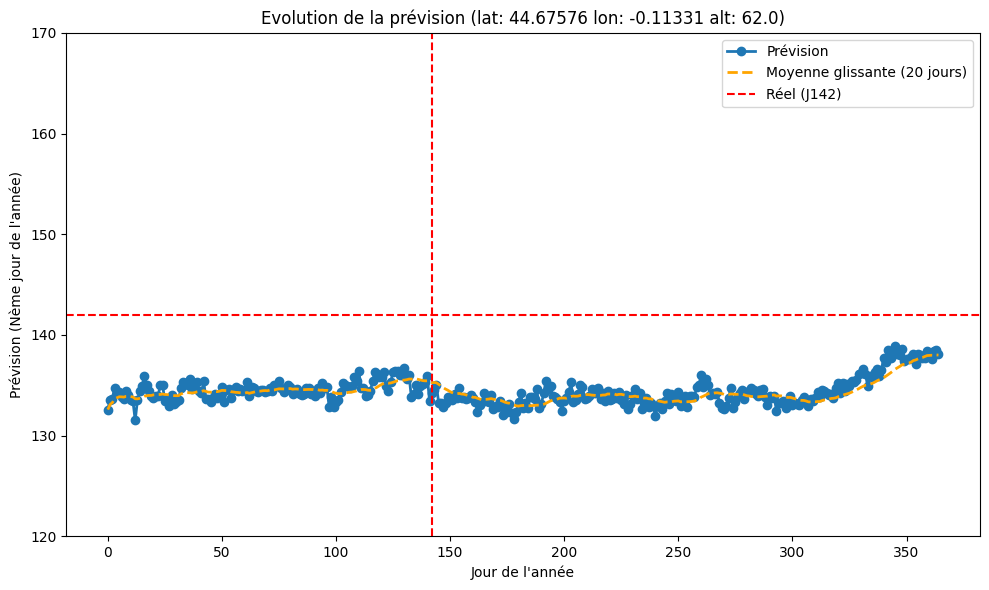

Date moyenne prévue : 14 May 2017 (J134)
Date réelle         : 22 May 2017 (J142)


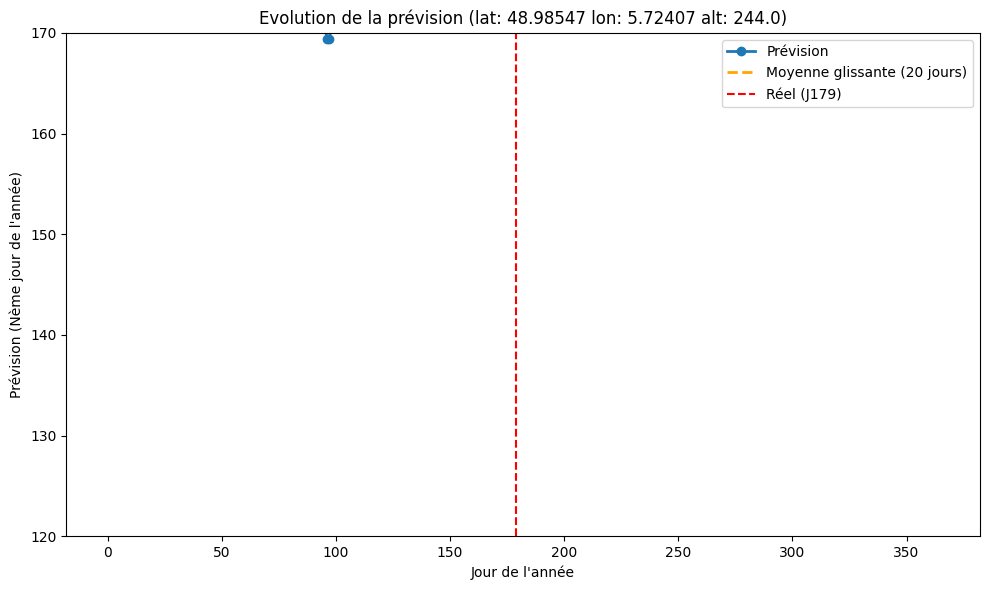

Date moyenne prévue : 24 June 2016 (J176)
Date réelle         : 27 June 2016 (J179)


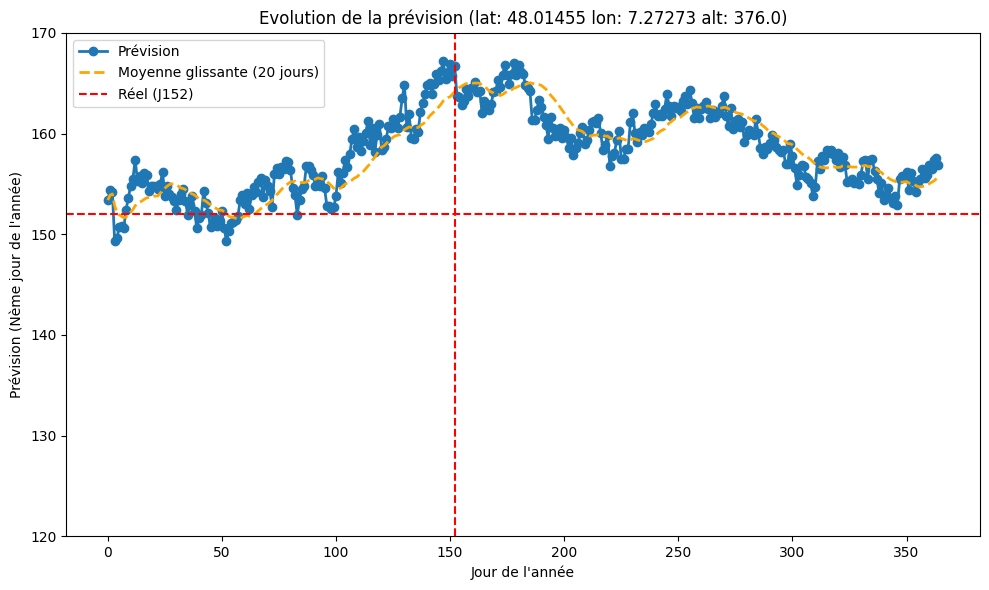

Date moyenne prévue : 07 June 2015 (J158)
Date réelle         : 01 June 2015 (J152)


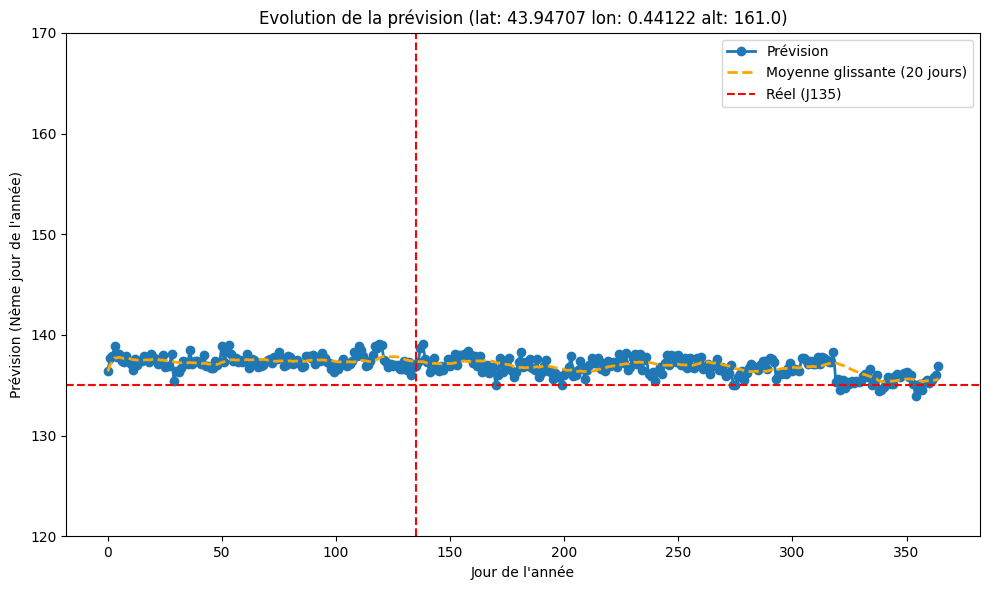

Date moyenne prévue : 17 May 2017 (J137)
Date réelle         : 15 May 2017 (J135)


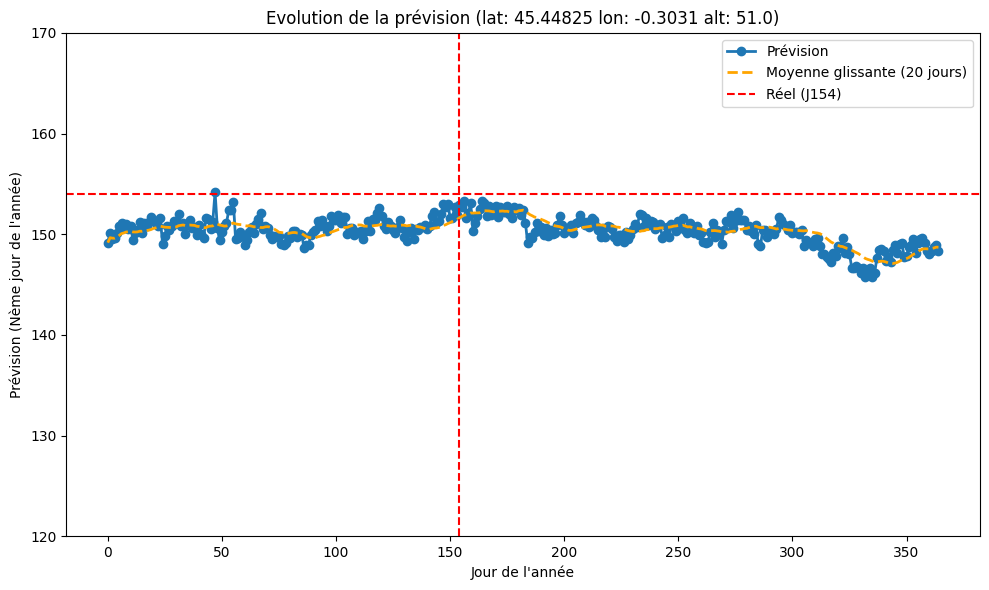

Date moyenne prévue : 30 May 2019 (J150)
Date réelle         : 03 June 2019 (J154)


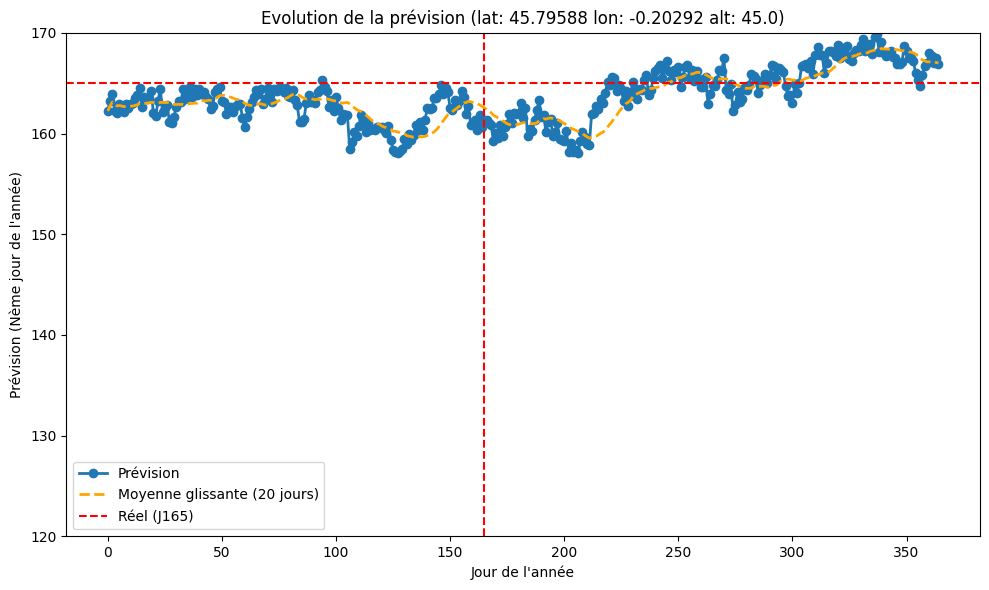

Date moyenne prévue : 13 June 2021 (J164)
Date réelle         : 14 June 2021 (J165)


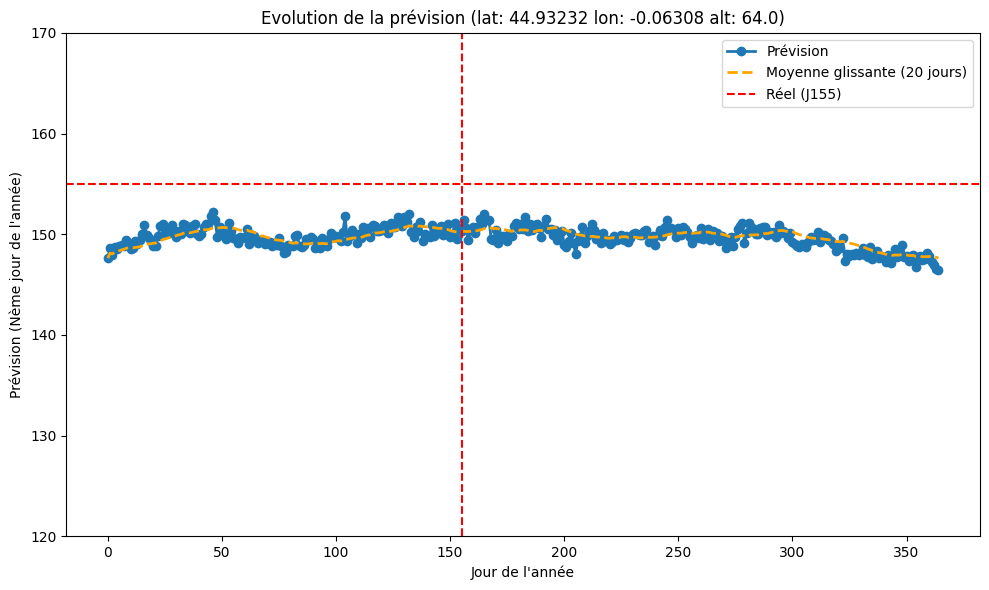

Date moyenne prévue : 30 May 2019 (J150)
Date réelle         : 04 June 2019 (J155)


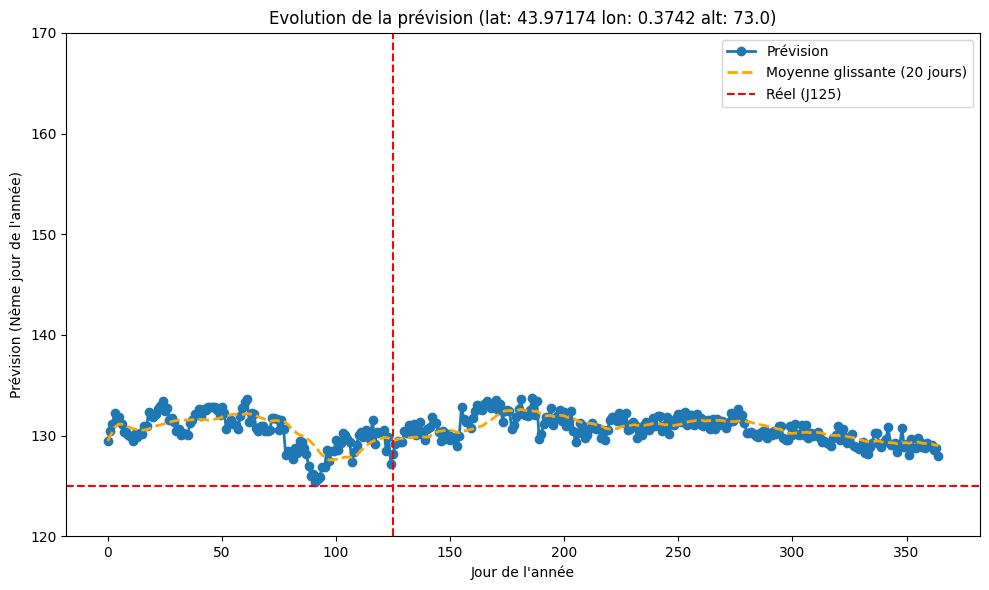

Date moyenne prévue : 10 May 2020 (J131)
Date réelle         : 04 May 2020 (J125)


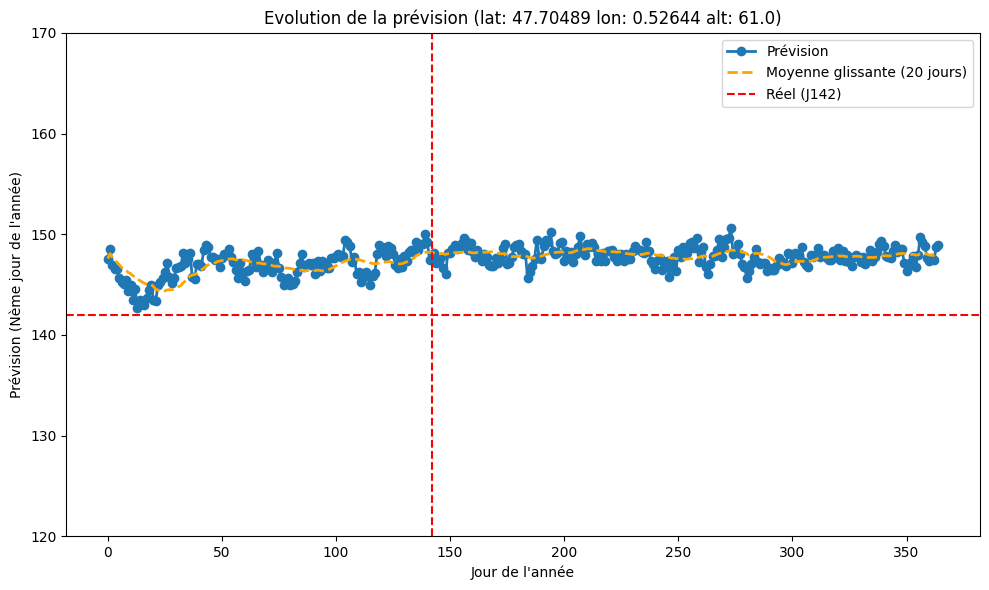

Date moyenne prévue : 27 May 2018 (J147)
Date réelle         : 22 May 2018 (J142)


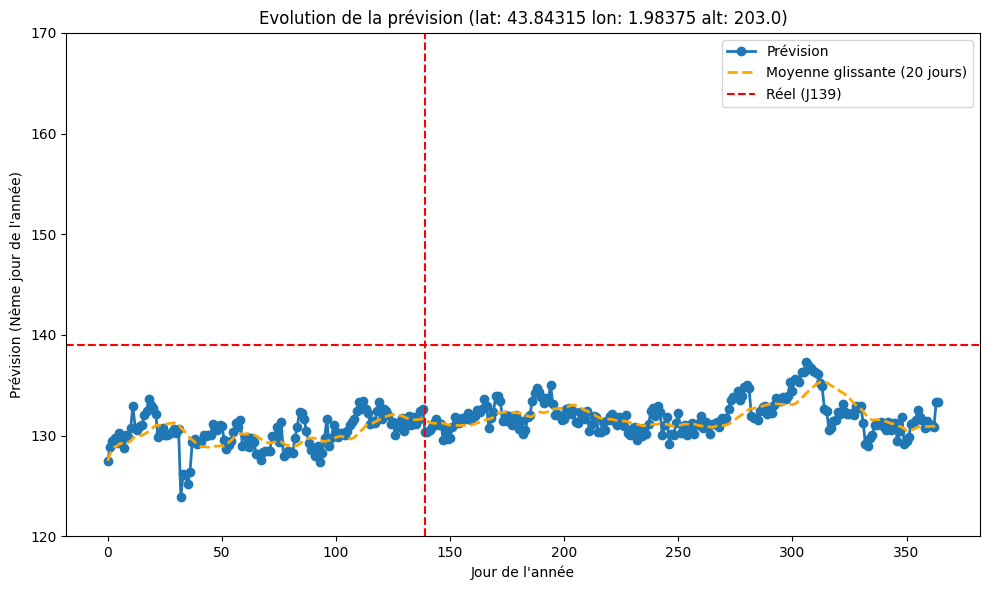

Date moyenne prévue : 10 May 2020 (J131)
Date réelle         : 18 May 2020 (J139)


In [29]:
#Affichage des visualisations

for index, row in df_source.iterrows():
    build_visualisation(
        lat=row["latitude_du_site"],
        lon=row["longitude_du_site"],
        alt=row["altitude_du_site_ign"],
        real_date=row["date"]
    )

## Comparaison de prévisions sur des cas rééls issus d'une source complémentaires

Afin de valider la démarche et la capacité de généralisation j'applique le modèle et je compare la prévision obtenue à des dates réelles constatées par une source non incluse dans les données d'entraînement, en l'occurence le Comité Interprofessionnel des Vins d'Alsace (CIVA) dont les données de constatation de phénologie sont disponibles à l'url suivante : https://technique.vinsalsace.pro/index.php?p=pheno

## Bergheim - 2018 - Riesling
Latitude : 50.955051 - Longitude : 6.639990 - Date constatée : 29 mai - Altitude : 211m

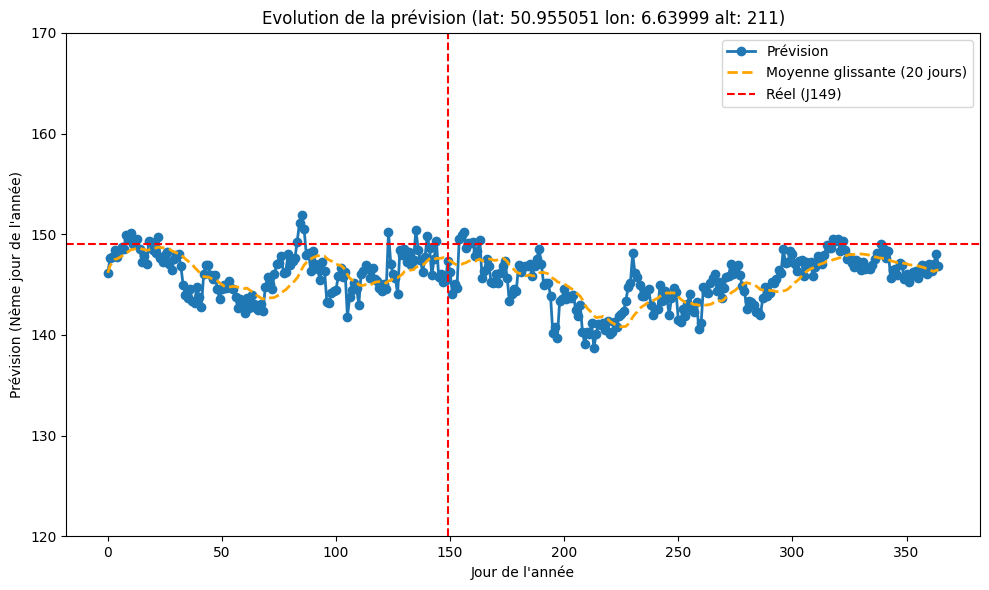

Date moyenne prévue : 26 May 2018 (J146)
Date réelle         : 29 May 2018 (J149)


In [32]:
build_visualisation(
    lat=50.955051,
    lon=6.639990,
    alt=211,
    real_date="2018-05-29"
)

## Bergheim - 2011 - Getwurtzraminer
Latitude : 50.955051 - Longitude : 6.639990 - Date constatée : 26 mai - Altitude : 211m

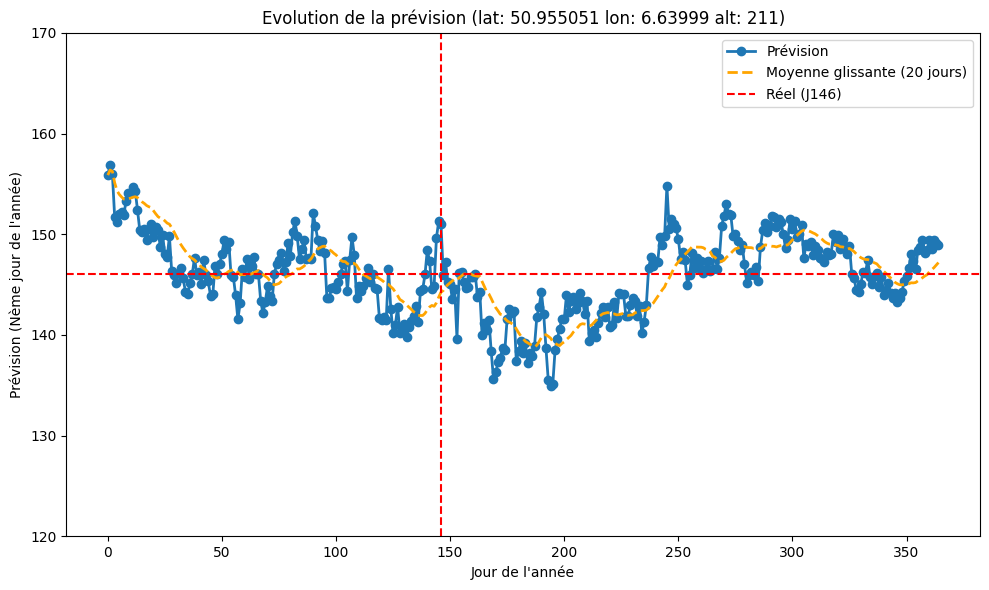

Date moyenne prévue : 26 May 2011 (J146)
Date réelle         : 26 May 2011 (J146)


In [38]:
build_visualisation(
    lat=50.955051,
    lon=6.639990,
    alt=211,
    real_date="2011-05-26"
)

## Bergheim - 2014 - Riesling
Latitude : 50.955051 - Longitude : 6.639990 - Date constatée : 8 juin - Altitude : 211m

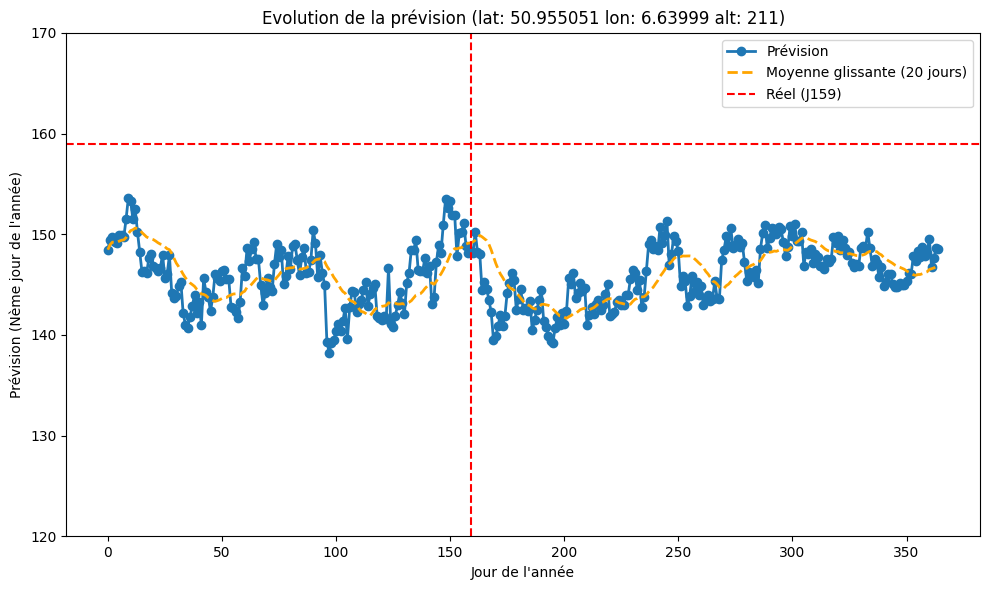

Date moyenne prévue : 26 May 2014 (J146)
Date réelle         : 08 June 2014 (J159)


In [40]:
build_visualisation(
    lat=50.955051,
    lon=6.639990,
    alt=211,
    real_date="2014-06-08"
)